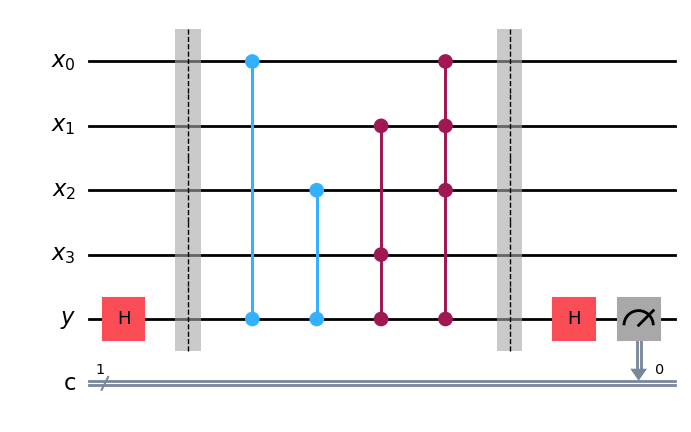

In [6]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate
inputs = QuantumRegister(4, name='x')
ancilla = QuantumRegister(1, name='y')
c_reg = ClassicalRegister(1, name='c')

qc = QuantumCircuit(inputs, ancilla, c_reg)

qc.h(ancilla[0])

qc.barrier()

qc.cz(inputs[0], ancilla[0])

qc.cz(inputs[2], ancilla[0])

qc.ccz(inputs[1], inputs[3], ancilla[0])

cccz_gate = ZGate().control(num_ctrl_qubits=3)
qc.append(cccz_gate, [inputs[0], inputs[1], inputs[2], ancilla[0]])

qc.barrier() 

qc.h(ancilla[0])
qc.measure(ancilla[0], c_reg[0])

qc.draw("mpl")

# Quantum Oracle Circuit using Qiskit

This project implements a quantum oracle for the Boolean function:

\[
f(x_1, x_2, x_3, x_4)
=
x_1 \oplus x_3 \oplus x_2x_4 \oplus x_1x_2x_3
\]

using controlled phase operations in Qiskit.

---

## Imports

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate
```

These modules are used for:

- Creating quantum and classical registers
- Building quantum circuits
- Creating multi-controlled Z gates

---

## Register Initialization

```python
inputs = QuantumRegister(4, name='x')
ancilla = QuantumRegister(1, name='y')
c_reg = ClassicalRegister(1, name='c')
```

### Registers

- `inputs` : 4 input qubits
- `ancilla` : 1 ancilla/output qubit
- `c_reg` : 1 classical bit for measurement

---

## Circuit Creation

```python
qc = QuantumCircuit(inputs, ancilla, c_reg)
```

Creates the quantum circuit.

---

## Ancilla Preparation

```python
qc.h(ancilla[0])
```

The ancilla qubit is initialized in the state:

\[
|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
\]

This enables phase kickback for oracle implementation.

---

## Oracle Construction

### Linear Terms

```python
qc.cz(inputs[0], ancilla[0])
qc.cz(inputs[2], ancilla[0])
```

These apply phase flips corresponding to:

\[
x_1 \quad \text{and} \quad x_3
\]

---

### Quadratic Term

```python
qc.ccz(inputs[1], inputs[3], ancilla[0])
```

Implements the term:

\[
x_2x_4
\]

using a controlled-controlled-Z gate.

---

### Cubic Term

```python
cccz_gate = ZGate().control(num_ctrl_qubits=3)
qc.append(cccz_gate, [inputs[0], inputs[1], inputs[2], ancilla[0]])
```

Implements the term:

\[
x_1x_2x_3
\]

using a triple-controlled Z gate.

---

## Measurement

```python
qc.h(ancilla[0])
qc.measure(ancilla[0], c_reg[0])
```

The final Hadamard converts phase information into measurable amplitudes before measurement.

---

## Circuit Visualization

```python
qc.draw("mpl")
```

Draws the circuit using Matplotlib.

---

## Complete Code

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate

inputs = QuantumRegister(4, name='x')
ancilla = QuantumRegister(1, name='y')
c_reg = ClassicalRegister(1, name='c')

qc = QuantumCircuit(inputs, ancilla, c_reg)

qc.h(ancilla[0])

qc.barrier()

qc.cz(inputs[0], ancilla[0])

qc.cz(inputs[2], ancilla[0])

qc.ccz(inputs[1], inputs[3], ancilla[0])

cccz_gate = ZGate().control(num_ctrl_qubits=3)
qc.append(cccz_gate, [inputs[0], inputs[1], inputs[2], ancilla[0]])

qc.barrier()

qc.h(ancilla[0])

qc.measure(ancilla[0], c_reg[0])

qc.draw("mpl")
```

---

## Implemented Boolean Polynomial

\[
f(x_1, x_2, x_3, x_4)
=
x_1 \oplus x_3 \oplus x_2x_4 \oplus x_1x_2x_3
\]

where:

- \(\oplus\) denotes XOR
- Multiplication denotes logical AND

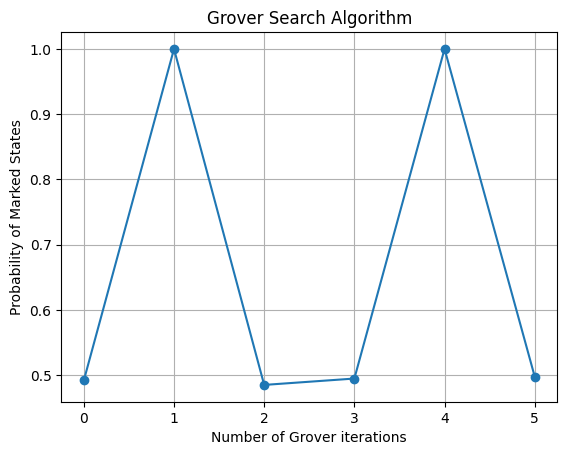

In [17]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit import transpile

def Zf_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)
    qc.cz(inputs[0], ancilla[0])

    qc.cz(inputs[2], ancilla[0])

    qc.ccz(inputs[1], inputs[3], ancilla[0])

    cccz_gate = ZGate().control(num_ctrl_qubits=3)
    qc.append(cccz_gate, [inputs[0], inputs[1], inputs[2], ancilla[0]])

    return qc

def ZOR_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)
    qc.x(inputs)
    qc.mcx(inputs, ancilla[0])
    qc.x(inputs)
    qc.x(ancilla[0])
    return qc

def G_operation(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)
    qc.compose(
        Zf_oracle(inputs,ancilla),
        inplace = True
    )
    qc.h(inputs)
    qc.compose(
        ZOR_oracle(inputs,ancilla),
        inplace = True
    )
    qc.h(inputs)
    return qc
marked_states = ['0001', '0011', '0100', '0110', '0111', '1001', '1010','1100']
sim = AerSimulator()
iterations_list = []
probabilities =[]
for k in range(6):
    inputs = QuantumRegister(4,"x")
    ancilla = QuantumRegister(1,"y")
    c_reg = ClassicalRegister(4,"c")

    qc = QuantumCircuit(inputs,ancilla,c_reg)
    qc.h(inputs)
    qc.x(ancilla[0])
    qc.h(ancilla[0])
    for t in range(k):
        qc.compose(
        G_operation(inputs, ancilla),
        inplace = True
        )
    qc.measure(inputs,c_reg)
    qc.draw("mpl")

    tqc = transpile(qc, sim)
    job = sim.run(tqc, shots=1024)
    result = job.result()
    counts = result.get_counts()
    success_counts = 0
    for state in marked_states:
        success_counts += counts.get(state,0)
    probability = success_counts/1024
    iterations_list.append(k)
    probabilities.append(probability)    
plt.plot(iterations_list, probabilities, marker ='o')
plt.xlabel("Number of Grover iterations")
plt.ylabel("Probability of Marked States")
plt.title("Grover Search Algorithm")
plt.grid(True)
plt.show()

# Grover Search Algorithm using Qiskit

This project implements the **Grover Search Algorithm** for multiple marked states using Qiskit.

The oracle is constructed from the Boolean polynomial:

\[
f(x_1,x_2,x_3,x_4)
=
x_1 \oplus x_3 \oplus x_2x_4 \oplus x_1x_2x_3
\]

The simulation measures how the probability of obtaining marked states changes with the number of Grover iterations.

---

# Imports

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit import transpile
```

These libraries are used for:

- Constructing quantum circuits
- Creating controlled phase gates
- Running simulations
- Plotting probability graphs

---

# Oracle Construction

## Phase Oracle

```python
def Zf_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.cz(inputs[0], ancilla[0])

    qc.cz(inputs[2], ancilla[0])

    qc.ccz(inputs[1], inputs[3], ancilla[0])

    cccz_gate = ZGate().control(num_ctrl_qubits=3)
    qc.append(cccz_gate, [inputs[0], inputs[1], inputs[2], ancilla[0]])

    return qc
```

This oracle applies phase flips corresponding to the Boolean function:

\[
f(x_1,x_2,x_3,x_4)
=
x_1 \oplus x_3 \oplus x_2x_4 \oplus x_1x_2x_3
\]

Implemented terms:

| Boolean Term | Quantum Operation |
|---|---|
| \(x_1\) | CZ gate |
| \(x_3\) | CZ gate |
| \(x_2x_4\) | CCZ gate |
| \(x_1x_2x_3\) | CCCZ gate |

---

# Diffusion Operator

## Zero-State Oracle

```python
def ZOR_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.x(inputs)

    qc.mcx(inputs, ancilla[0])

    qc.x(inputs)

    qc.x(ancilla[0])

    return qc
```

This operator marks the \(|0000\rangle\) state and is used inside the Grover diffusion step.

---

# Grover Iteration Operator

```python
def G_operation(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.compose(
        Zf_oracle(inputs, ancilla),
        inplace=True
    )

    qc.h(inputs)

    qc.compose(
        ZOR_oracle(inputs, ancilla),
        inplace=True
    )

    qc.h(inputs)

    return qc
```

The Grover operator consists of:

1. Oracle application
2. Hadamard transform
3. Diffusion operator
4. Final Hadamard transform

---

# Marked States

```python
marked_states = [
    '0001',
    '0011',
    '0100',
    '0110',
    '0111',
    '1001',
    '1010',
    '1100'
]
```

These are the target states satisfying the Boolean function.

---

# Simulation

```python
sim = AerSimulator()

iterations_list = []
probabilities = []
```

The Aer simulator is used to execute the quantum circuit.

---

# Running Grover Iterations

```python
for k in range(6):
```

The circuit is executed for different numbers of Grover iterations from 0 to 5.

---

## Circuit Initialization

```python
inputs = QuantumRegister(4, "x")
ancilla = QuantumRegister(1, "y")
c_reg = ClassicalRegister(4, "c")

qc = QuantumCircuit(inputs, ancilla, c_reg)
```

Creates:

- 4 input qubits
- 1 ancilla qubit
- 4 classical bits

---

## State Preparation

```python
qc.h(inputs)

qc.x(ancilla[0])
qc.h(ancilla[0])
```

Initializes:

- Input qubits into equal superposition
- Ancilla into:

\[
|-\rangle
=
\frac{|0\rangle - |1\rangle}{\sqrt{2}}
\]

---

## Applying Grover Iterations

```python
for t in range(k):
    qc.compose(
        G_operation(inputs, ancilla),
        inplace=True
    )
```

Applies the Grover operator \(k\) times.

---

## Measurement

```python
qc.measure(inputs, c_reg)
```

Measures all input qubits.

---

# Circuit Visualization

```python
qc.draw("mpl")
```

Displays the circuit using Matplotlib.

---

# Simulation Execution

```python
tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()
```

The circuit is:

1. Transpiled
2. Simulated
3. Measured over 1024 shots

---

# Probability Calculation

```python
success_counts = 0

for state in marked_states:
    success_counts += counts.get(state, 0)

probability = success_counts / 1024
```

Computes the probability of measuring any marked state.

---

# Storing Results

```python
iterations_list.append(k)

probabilities.append(probability)
```

Stores:

- Number of Grover iterations
- Corresponding success probability

---

# Plotting Results

```python
plt.plot(iterations_list, probabilities, marker='o')

plt.xlabel("Number of Grover iterations")

plt.ylabel("Probability of Marked States")

plt.title("Grover Search Algorithm")

plt.grid(True)

plt.show()
```

Plots the probability of measuring marked states versus the number of Grover iterations.

---

# Complete Code

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit import transpile

def Zf_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.cz(inputs[0], ancilla[0])

    qc.cz(inputs[2], ancilla[0])

    qc.ccz(inputs[1], inputs[3], ancilla[0])

    cccz_gate = ZGate().control(num_ctrl_qubits=3)
    qc.append(cccz_gate, [inputs[0], inputs[1], inputs[2], ancilla[0]])

    return qc

def ZOR_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.x(inputs)

    qc.mcx(inputs, ancilla[0])

    qc.x(inputs)

    qc.x(ancilla[0])

    return qc

def G_operation(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.compose(
        Zf_oracle(inputs, ancilla),
        inplace=True
    )

    qc.h(inputs)

    qc.compose(
        ZOR_oracle(inputs, ancilla),
        inplace=True
    )

    qc.h(inputs)

    return qc

marked_states = [
    '0001',
    '0011',
    '0100',
    '0110',
    '0111',
    '1001',
    '1010',
    '1100'
]

sim = AerSimulator()

iterations_list = []
probabilities = []

for k in range(6):

    inputs = QuantumRegister(4, "x")
    ancilla = QuantumRegister(1, "y")
    c_reg = ClassicalRegister(4, "c")

    qc = QuantumCircuit(inputs, ancilla, c_reg)

    qc.h(inputs)

    qc.x(ancilla[0])
    qc.h(ancilla[0])

    for t in range(k):
        qc.compose(
            G_operation(inputs, ancilla),
            inplace=True
        )

    qc.measure(inputs, c_reg)

    qc.draw("mpl")

    tqc = transpile(qc, sim)

    job = sim.run(tqc, shots=1024)

    result = job.result()

    counts = result.get_counts()

    success_counts = 0

    for state in marked_states:
        success_counts += counts.get(state, 0)

    probability = success_counts / 1024

    iterations_list.append(k)

    probabilities.append(probability)

plt.plot(iterations_list, probabilities, marker='o')

plt.xlabel("Number of Grover iterations")

plt.ylabel("Probability of Marked States")

plt.title("Grover Search Algorithm")

plt.grid(True)

plt.show()
```

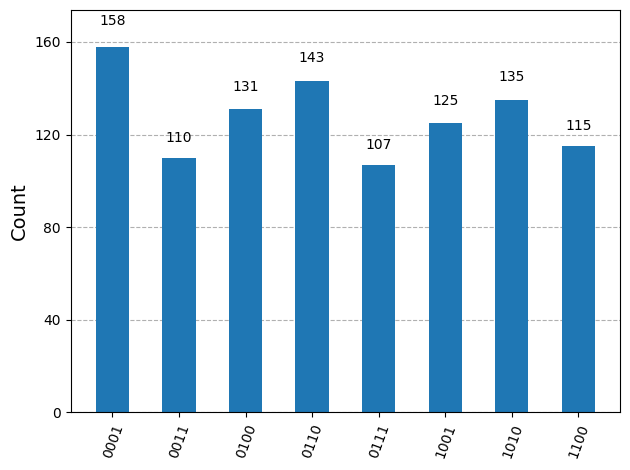

In [19]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit import transpile

def Zf_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)
    qc.cz(inputs[0], ancilla[0])

    qc.cz(inputs[2], ancilla[0])

    qc.ccz(inputs[1], inputs[3], ancilla[0])

    cccz_gate = ZGate().control(num_ctrl_qubits=3)
    qc.append(cccz_gate, [inputs[0], inputs[1], inputs[2], ancilla[0]])

    return qc

def ZOR_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)
    qc.x(inputs)
    qc.mcx(inputs, ancilla[0])
    qc.x(inputs)
    qc.x(ancilla[0])
    return qc

def G_operation(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)
    qc.compose(
        Zf_oracle(inputs,ancilla),
        inplace = True
    )
    qc.h(inputs)
    qc.compose(
        ZOR_oracle(inputs,ancilla),
        inplace = True
    )
    qc.h(inputs)
    return qc
sim = AerSimulator()
inputs = QuantumRegister(4,"x")
ancilla = QuantumRegister(1,"y")
c_reg = ClassicalRegister(4,"c")

qc = QuantumCircuit(inputs,ancilla,c_reg)
qc.h(inputs)
qc.x(ancilla[0])
qc.h(ancilla[0])
qc.compose(
   G_operation(inputs, ancilla),
   inplace = True
        )
qc.measure(inputs,c_reg)
qc.draw("mpl")

tqc = transpile(qc, sim)
job = sim.run(tqc, shots=1024)
result = job.result()
counts = result.get_counts()    
plot_histogram(counts)
display(plot_histogram(counts))

# Single Iteration Grover Search using Qiskit

This implementation demonstrates a **single iteration** of the Grover Search Algorithm using Qiskit.

The oracle is constructed from the Boolean polynomial:

\[
f(x_1,x_2,x_3,x_4)
=
x_1 \oplus x_3 \oplus x_2x_4 \oplus x_1x_2x_3
\]

The circuit is simulated using the Aer simulator, and the resulting measurement distribution is displayed using a histogram.

---

# Imports

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit import transpile
```

These libraries are used for:

- Constructing quantum circuits
- Creating multi-controlled gates
- Running simulations
- Visualizing measurement results

---

# Oracle Construction

## Phase Oracle

```python
def Zf_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.cz(inputs[0], ancilla[0])

    qc.cz(inputs[2], ancilla[0])

    qc.ccz(inputs[1], inputs[3], ancilla[0])

    cccz_gate = ZGate().control(num_ctrl_qubits=3)

    qc.append(
        cccz_gate,
        [inputs[0], inputs[1], inputs[2], ancilla[0]]
    )

    return qc
```

This oracle implements the Boolean function:

\[
f(x_1,x_2,x_3,x_4)
=
x_1 \oplus x_3 \oplus x_2x_4 \oplus x_1x_2x_3
\]

using:

- CZ gates
- CCZ gate
- CCCZ gate

---

# Zero-State Oracle

```python
def ZOR_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.x(inputs)

    qc.mcx(inputs, ancilla[0])

    qc.x(inputs)

    qc.x(ancilla[0])

    return qc
```

This operator marks the \(|0000\rangle\) state and is used in the Grover diffusion step.

---

# Grover Operator

```python
def G_operation(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.compose(
        Zf_oracle(inputs, ancilla),
        inplace=True
    )

    qc.h(inputs)

    qc.compose(
        ZOR_oracle(inputs, ancilla),
        inplace=True
    )

    qc.h(inputs)

    return qc
```

The Grover iteration consists of:

1. Oracle application
2. Hadamard transformation
3. Diffusion operator
4. Final Hadamard transformation

---

# Circuit Initialization

```python
sim = AerSimulator()

inputs = QuantumRegister(4, "x")

ancilla = QuantumRegister(1, "y")

c_reg = ClassicalRegister(4, "c")
```

Creates:

- 4 input qubits
- 1 ancilla qubit
- 4 classical bits
- Aer quantum simulator

---

# Quantum Circuit Creation

```python
qc = QuantumCircuit(inputs, ancilla, c_reg)
```

Initializes the complete quantum circuit.

---

# State Preparation

```python
qc.h(inputs)

qc.x(ancilla[0])

qc.h(ancilla[0])
```

The input qubits are placed into equal superposition.

The ancilla qubit is initialized into the state:

\[
|-\rangle
=
\frac{|0\rangle - |1\rangle}{\sqrt{2}}
\]

for phase kickback.

---

# Applying One Grover Iteration

```python
qc.compose(
   G_operation(inputs, ancilla),
   inplace=True
)
```

Applies a single Grover iteration to amplify the amplitudes of marked states.

---

# Measurement

```python
qc.measure(inputs, c_reg)
```

Measures all input qubits.

---

# Circuit Visualization

```python
qc.draw("mpl")
```

Draws the quantum circuit using Matplotlib.

---

# Simulation

```python
tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()
```

Steps:

1. Transpile the circuit
2. Execute on the Aer simulator
3. Collect measurement results

---

# Histogram Visualization

```python
plot_histogram(counts)

display(plot_histogram(counts))
```

Displays a histogram showing the probability distribution of measured states after one Grover iteration.

---

# Complete Code

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit import transpile

def Zf_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.cz(inputs[0], ancilla[0])

    qc.cz(inputs[2], ancilla[0])

    qc.ccz(inputs[1], inputs[3], ancilla[0])

    cccz_gate = ZGate().control(num_ctrl_qubits=3)

    qc.append(
        cccz_gate,
        [inputs[0], inputs[1], inputs[2], ancilla[0]]
    )

    return qc

def ZOR_oracle(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.x(inputs)

    qc.mcx(inputs, ancilla[0])

    qc.x(inputs)

    qc.x(ancilla[0])

    return qc

def G_operation(inputs, ancilla):
    qc = QuantumCircuit(inputs, ancilla)

    qc.compose(
        Zf_oracle(inputs, ancilla),
        inplace=True
    )

    qc.h(inputs)

    qc.compose(
        ZOR_oracle(inputs, ancilla),
        inplace=True
    )

    qc.h(inputs)

    return qc

sim = AerSimulator()

inputs = QuantumRegister(4, "x")

ancilla = QuantumRegister(1, "y")

c_reg = ClassicalRegister(4, "c")

qc = QuantumCircuit(inputs, ancilla, c_reg)

qc.h(inputs)

qc.x(ancilla[0])

qc.h(ancilla[0])

qc.compose(
   G_operation(inputs, ancilla),
   inplace=True
)

qc.measure(inputs, c_reg)

qc.draw("mpl")

tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()

plot_histogram(counts)

display(plot_histogram(counts))
```

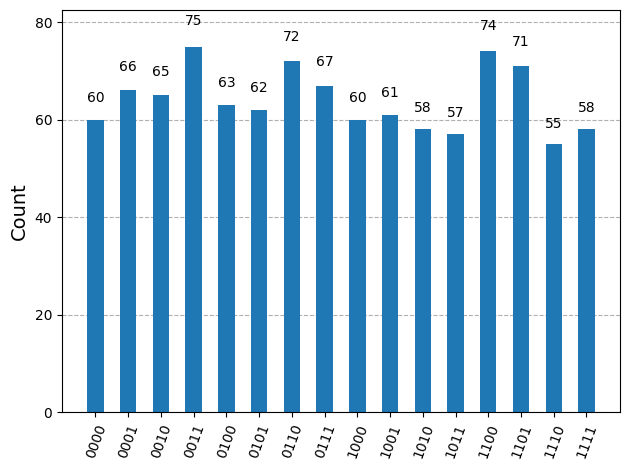

In [8]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)
    gate = UnitaryGate(u, label = f"uROT{k}")
    return gate.control(1)
def QFT(inputs):
    qc = QuantumCircuit(inputs)
    n = len(inputs)
    for t in reversed(range(n)):
        qc.h(inputs[t])
        for ctrl in reversed(range(t+1,n)):
            k = ctrl-t+1
            qc.append(u_ROT(k), [inputs[ctrl],inputs[t]])
    for i in range(n//2):
        qc.swap(inputs[i],inputs[n-i-1])
    gate = qc.to_gate(label= f"QFT{n}")
    return gate
inputs = QuantumRegister(4, "x")
c_reg = ClassicalRegister(4, "c")
qc = QuantumCircuit(inputs,c_reg)
qc.x(inputs[3])
qc.append(QFT(inputs), inputs)
qc.measure(inputs,c_reg)
qc.draw("mpl")
sim = AerSimulator()
tqc = transpile(qc, sim)
job = sim.run(tqc, shots=1024)
result = job.result()
counts = result.get_counts()    
plot_histogram(counts)
display(plot_histogram(counts))

# Quantum Fourier Transform (QFT) using Qiskit

This project implements the **Quantum Fourier Transform (QFT)** for a 4-qubit quantum system using Qiskit.

The circuit:

1. Constructs controlled phase rotation gates
2. Builds a custom QFT circuit
3. Applies QFT to an input basis state
4. Simulates the circuit using AerSimulator
5. Displays the measurement distribution using a histogram

---

# Imports

```python
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
```

These libraries are used for:

- Creating quantum circuits
- Constructing custom unitary gates
- Running simulations
- Visualizing output distributions

---

# Controlled Rotation Gate

## Definition

```python
def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)

    gate = UnitaryGate(u, label = f"uROT{k}")

    return gate.control(1)
```

This function creates a controlled phase rotation gate:

\[
R_k =
\begin{bmatrix}
1 & 0 \\
0 & e^{\frac{2\pi i}{2^k}}
\end{bmatrix}
\]

where:

- \(k\) determines the rotation angle
- The gate is converted into a controlled gate

---

# Quantum Fourier Transform Circuit

## QFT Function

```python
def QFT(inputs):
    qc = QuantumCircuit(inputs)

    n = len(inputs)

    for t in reversed(range(n)):

        qc.h(inputs[t])

        for ctrl in reversed(range(t+1,n)):

            k = ctrl - t + 1

            qc.append(
                u_ROT(k),
                [inputs[ctrl], inputs[t]]
            )

    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])

    gate = qc.to_gate(label=f"QFT{n}")

    return gate
```

This function constructs the QFT circuit using:

- Hadamard gates
- Controlled phase rotations
- Final swap operations

---

# QFT Structure

For each qubit:

1. Apply a Hadamard gate
2. Apply controlled rotation gates from higher-index qubits
3. Reverse qubit order using swap gates

The final swap stage corrects the bit ordering of the QFT output.

---

# Register Initialization

```python
inputs = QuantumRegister(4, "x")

c_reg = ClassicalRegister(4, "c")
```

Creates:

- 4 quantum input qubits
- 4 classical bits for measurement

---

# Circuit Creation

```python
qc = QuantumCircuit(inputs, c_reg)
```

Initializes the quantum circuit.

---

# Input State Preparation

```python
qc.x(inputs[3])
```

This prepares the computational basis state:

\[
|0001\rangle
\]

before applying the QFT.

---

# Applying the QFT

```python
qc.append(QFT(inputs), inputs)
```

Applies the custom 4-qubit QFT gate to the input register.

---

# Measurement

```python
qc.measure(inputs, c_reg)
```

Measures all qubits.

---

# Circuit Visualization

```python
qc.draw("mpl")
```

Displays the circuit using Matplotlib.

---

# Simulation

```python
sim = AerSimulator()

tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()
```

Steps:

1. Create Aer simulator
2. Transpile the circuit
3. Execute the simulation
4. Collect measurement counts

---

# Histogram Visualization

```python
plot_histogram(counts)

display(plot_histogram(counts))
```

Displays the probability distribution of measured output states after the QFT operation.

---

# Complete Code

```python
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype=complex)

    gate = UnitaryGate(u, label=f"uROT{k}")

    return gate.control(1)

def QFT(inputs):
    qc = QuantumCircuit(inputs)

    n = len(inputs)

    for t in reversed(range(n)):

        qc.h(inputs[t])

        for ctrl in reversed(range(t+1, n)):

            k = ctrl - t + 1

            qc.append(
                u_ROT(k),
                [inputs[ctrl], inputs[t]]
            )

    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])

    gate = qc.to_gate(label=f"QFT{n}")

    return gate

inputs = QuantumRegister(4, "x")

c_reg = ClassicalRegister(4, "c")

qc = QuantumCircuit(inputs, c_reg)

qc.x(inputs[3])

qc.append(QFT(inputs), inputs)

qc.measure(inputs, c_reg)

qc.draw("mpl")

sim = AerSimulator()

tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()

plot_histogram(counts)

display(plot_histogram(counts))
```

---

# Mathematical Background

The Quantum Fourier Transform on an \(n\)-qubit state is defined as:

\[
QFT|x\rangle
=
\frac{1}{\sqrt{2^n}}
\sum_{y=0}^{2^n-1}
e^{\frac{2\pi ixy}{2^n}}
|y\rangle
\]

The QFT is a quantum analogue of the discrete Fourier transform and is widely used in:

- Shor’s Algorithm
- Phase Estimation
- Quantum Signal Processing
- Period Finding

---

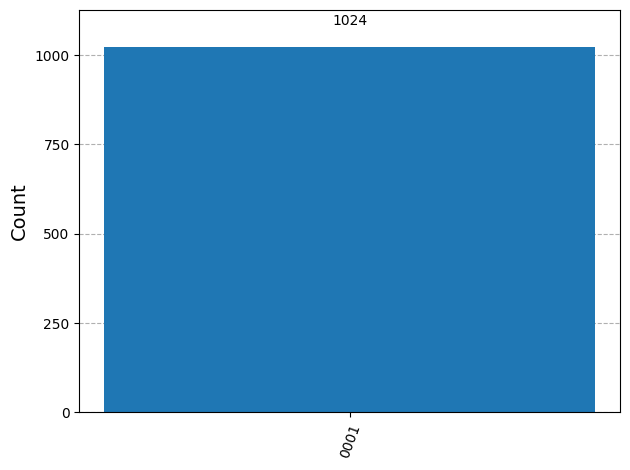

In [7]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)
    gate = UnitaryGate(u, label = f"uROT{k}")
    return gate.control(1)
def QFT(inputs):
    qc = QuantumCircuit(inputs)
    n = len(inputs)
    for t in reversed(range(n)):
        qc.h(inputs[t])
        for ctrl in reversed(range(t+1,n)):
            k = ctrl-t+1
            qc.append(u_ROT(k), [inputs[ctrl],inputs[t]])
    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])
    gate = qc.to_gate(label= f"QFT{n}")
    return gate
inputs = QuantumRegister(4, "x")
c_reg = ClassicalRegister(4, "c")
qc = QuantumCircuit(inputs,c_reg)
qc.x(inputs[0])
qc.append(QFT(inputs), inputs)
qc.append(QFT(inputs).inverse(),inputs)
qc.measure(inputs,c_reg)
qc.draw("mpl")
sim = AerSimulator()
tqc = transpile(qc, sim)
job = sim.run(tqc, shots=1024)
result = job.result()
counts = result.get_counts()    
plot_histogram(counts)
display(plot_histogram(counts))

# Quantum Fourier Transform and Inverse QFT using Qiskit

This project demonstrates the implementation of:

1. Quantum Fourier Transform (QFT)
2. Inverse Quantum Fourier Transform (QFT†)

using Qiskit.

The circuit:

- Prepares a computational basis state
- Applies the QFT
- Applies the inverse QFT
- Measures the final state

Since the inverse QFT reverses the QFT operation, the final measurement should reproduce the original input state.

---

# Imports

```python
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
```

These libraries are used for:

- Building quantum circuits
- Creating custom unitary gates
- Running simulations
- Visualizing results

---

# Controlled Rotation Gate

## Definition

```python
def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)

    gate = UnitaryGate(u, label = f"uROT{k}")

    return gate.control(1)
```

This function constructs the controlled phase rotation gate:

\[
R_k =
\begin{bmatrix}
1 & 0 \\
0 & e^{\frac{2\pi i}{2^k}}
\end{bmatrix}
\]

The gate is then converted into a controlled gate.

---

# Quantum Fourier Transform

## QFT Function

```python
def QFT(inputs):
    qc = QuantumCircuit(inputs)

    n = len(inputs)

    for t in reversed(range(n)):

        qc.h(inputs[t])

        for ctrl in reversed(range(t+1,n)):

            k = ctrl - t + 1

            qc.append(
                u_ROT(k),
                [inputs[ctrl], inputs[t]]
            )

    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])

    gate = qc.to_gate(label=f"QFT{n}")

    return gate
```

The QFT circuit is constructed using:

- Hadamard gates
- Controlled phase rotations
- Final swap operations

---

# Register Initialization

```python
inputs = QuantumRegister(4, "x")

c_reg = ClassicalRegister(4, "c")
```

Creates:

- 4 quantum input qubits
- 4 classical bits

---

# Circuit Creation

```python
qc = QuantumCircuit(inputs, c_reg)
```

Initializes the quantum circuit.

---

# Input State Preparation

```python
qc.x(inputs[0])
```

This prepares the computational basis state:

\[
|1000\rangle
\]

before applying the QFT.

---

# Applying the QFT

```python
qc.append(QFT(inputs), inputs)
```

Applies the 4-qubit Quantum Fourier Transform.

---

# Applying the Inverse QFT

```python
qc.append(QFT(inputs).inverse(), inputs)
```

Applies the inverse Quantum Fourier Transform:

\[
QFT^\dagger
\]

Since:

\[
QFT^\dagger QFT = I
\]

the combined operation should return the quantum state to its original form.

---

# Measurement

```python
qc.measure(inputs, c_reg)
```

Measures all qubits.

---

# Circuit Visualization

```python
qc.draw("mpl")
```

Displays the circuit using Matplotlib.

---

# Simulation

```python
sim = AerSimulator()

tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()
```

Steps:

1. Create simulator
2. Transpile the circuit
3. Execute simulation
4. Collect measurement results

---

# Histogram Visualization

```python
plot_histogram(counts)

display(plot_histogram(counts))
```

Displays the output probability distribution.

Since the inverse QFT perfectly reverses the QFT, the histogram should show the original input state with probability close to 1.

---

# Complete Code

```python
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype=complex)

    gate = UnitaryGate(u, label=f"uROT{k}")

    return gate.control(1)

def QFT(inputs):
    qc = QuantumCircuit(inputs)

    n = len(inputs)

    for t in reversed(range(n)):

        qc.h(inputs[t])

        for ctrl in reversed(range(t+1, n)):

            k = ctrl - t + 1

            qc.append(
                u_ROT(k),
                [inputs[ctrl], inputs[t]]
            )

    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])

    gate = qc.to_gate(label=f"QFT{n}")

    return gate

inputs = QuantumRegister(4, "x")

c_reg = ClassicalRegister(4, "c")

qc = QuantumCircuit(inputs, c_reg)

qc.x(inputs[0])

qc.append(QFT(inputs), inputs)

qc.append(QFT(inputs).inverse(), inputs)

qc.measure(inputs, c_reg)

qc.draw("mpl")

sim = AerSimulator()

tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()

plot_histogram(counts)

display(plot_histogram(counts))
```

---

# Mathematical Background

The Quantum Fourier Transform is defined as:

\[
QFT|x\rangle
=
\frac{1}{\sqrt{2^n}}
\sum_{y=0}^{2^n-1}
e^{\frac{2\pi ixy}{2^n}}
|y\rangle
\]

The inverse QFT satisfies:

\[
QFT^\dagger QFT = I
\]

which means the inverse operation perfectly reconstructs the original quantum state.

---

# Expected Result

Because the circuit applies:

\[
QFT^\dagger(QFT(|1000\rangle))
\]

the final measurement should return:

\[
|1000\rangle
\]

with probability close to 100%.

---

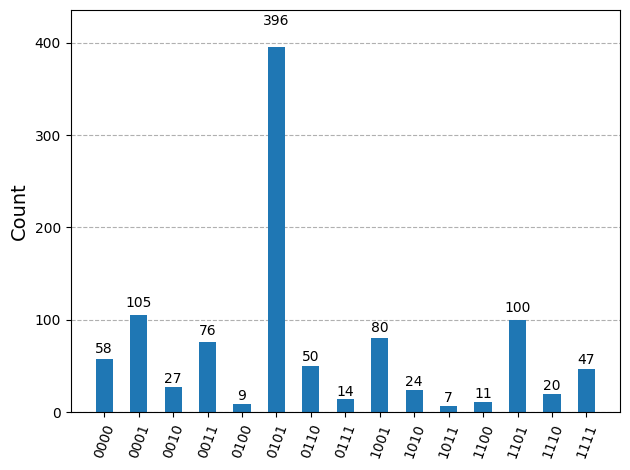

In [12]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)
    gate = UnitaryGate(u, label = f"uROT{k}")
    return gate.control(1)
def QFT(inputs):
    qc = QuantumCircuit(inputs)
    n = len(inputs)
    for t in reversed(range(n)):
        qc.h(inputs[t])
        for ctrl in reversed(range(t+1,n)):
            k = ctrl-t+1
            qc.append(u_ROT(k), [inputs[ctrl],inputs[t]])
    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])
    gate = qc.to_gate(label= f"QFT{n}")
    return gate
def u_op_k(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j*k/3)]
    ], dtype = complex)
    gate = UnitaryGate(u, label = "U")
    return gate.control(1)
estimation = QuantumRegister(4,"x")
unitary = QuantumRegister(1,"y")
c_reg = ClassicalRegister(4,"c")
qc = QuantumCircuit(estimation, unitary, c_reg)
qc.h(estimation)
qc.x(unitary[0])
for t in range(4):
    qc.append(u_op_k(2**t), [estimation[t],unitary[0]])
qc.append(QFT(estimation).inverse(), estimation)
qc.measure(estimation, c_reg)
qc.draw("mpl")
sim = AerSimulator()
tqc = transpile(qc, sim)
job = sim.run(tqc, shots=1024)
result = job.result()
counts = result.get_counts()    
plot_histogram(counts)
display(plot_histogram(counts))

# Quantum Phase Estimation (QPE) using Qiskit

This project implements the **Quantum Phase Estimation (QPE)** algorithm using Qiskit.

The circuit estimates the phase of a unitary operator whose eigenvalue is:

\[
e^{2\pi i \theta}
\]

using:

- Controlled unitary operations
- Quantum Fourier Transform (QFT)
- Inverse QFT

The final measurement approximates the phase value encoded in the eigenstate.

---

# Imports

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
```

These libraries are used for:

- Creating quantum circuits
- Constructing custom unitary gates
- Running simulations
- Visualizing results

---

# Controlled Rotation Gate

## Definition

```python
def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)

    gate = UnitaryGate(u, label = f"uROT{k}")

    return gate.control(1)
```

This function constructs the controlled phase rotation gate:

\[
R_k =
\begin{bmatrix}
1 & 0 \\
0 & e^{\frac{2\pi i}{2^k}}
\end{bmatrix}
\]

used in the QFT circuit.

---

# Quantum Fourier Transform

## QFT Function

```python
def QFT(inputs):
    qc = QuantumCircuit(inputs)

    n = len(inputs)

    for t in reversed(range(n)):

        qc.h(inputs[t])

        for ctrl in reversed(range(t+1,n)):

            k = ctrl - t + 1

            qc.append(
                u_ROT(k),
                [inputs[ctrl], inputs[t]]
            )

    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])

    gate = qc.to_gate(label=f"QFT{n}")

    return gate
```

The QFT is implemented using:

- Hadamard gates
- Controlled phase rotations
- Final swap operations

---

# Controlled Unitary Operator

## Definition

```python
def u_op_k(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j*k/3)]
    ], dtype = complex)

    gate = UnitaryGate(u, label = "U")

    return gate.control(1)
```

This defines the controlled unitary operator:

\[
U^k =
\begin{bmatrix}
1 & 0 \\
0 & e^{2\pi i k/3}
\end{bmatrix}
\]

The phase encoded is:

\[
\theta = \frac{1}{3}
\]

---

# Register Initialization

```python
estimation = QuantumRegister(4,"x")

unitary = QuantumRegister(1,"y")

c_reg = ClassicalRegister(4,"c")
```

Creates:

- 4 estimation qubits
- 1 eigenstate qubit
- 4 classical bits

---

# Circuit Creation

```python
qc = QuantumCircuit(estimation, unitary, c_reg)
```

Initializes the quantum circuit.

---

# State Preparation

## Estimation Register

```python
qc.h(estimation)
```

Places all estimation qubits into equal superposition:

\[
\frac{1}{\sqrt{2^n}}
\sum_{x=0}^{2^n-1}|x\rangle
\]

---

## Eigenstate Preparation

```python
qc.x(unitary[0])
```

Prepares the eigenstate:

\[
|1\rangle
\]

which is an eigenvector of the unitary operator.

---

# Controlled Unitary Applications

```python
for t in range(4):
    qc.append(
        u_op_k(2**t),
        [estimation[t], unitary[0]]
    )
```

Applies controlled powers of the unitary:

\[
U^{2^0}, U^{2^1}, U^{2^2}, U^{2^3}
\]

These operations encode the phase information into the estimation register.

---

# Applying the Inverse QFT

```python
qc.append(
    QFT(estimation).inverse(),
    estimation
)
```

The inverse Quantum Fourier Transform extracts the encoded phase information.

---

# Measurement

```python
qc.measure(estimation, c_reg)
```

Measures the estimation register.

---

# Circuit Visualization

```python
qc.draw("mpl")
```

Displays the quantum circuit.

---

# Simulation

```python
sim = AerSimulator()

tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()
```

Steps:

1. Create simulator
2. Transpile the circuit
3. Execute the simulation
4. Collect measurement results

---

# Histogram Visualization

```python
plot_histogram(counts)

display(plot_histogram(counts))
```

Displays the probability distribution of measured phase estimates.

---

# Complete Code

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)

    gate = UnitaryGate(u, label = f"uROT{k}")

    return gate.control(1)

def QFT(inputs):
    qc = QuantumCircuit(inputs)

    n = len(inputs)

    for t in reversed(range(n)):

        qc.h(inputs[t])

        for ctrl in reversed(range(t+1,n)):

            k = ctrl - t + 1

            qc.append(
                u_ROT(k),
                [inputs[ctrl], inputs[t]]
            )

    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])

    gate = qc.to_gate(label=f"QFT{n}")

    return gate

def u_op_k(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j*k/3)]
    ], dtype = complex)

    gate = UnitaryGate(u, label = "U")

    return gate.control(1)

estimation = QuantumRegister(4, "x")

unitary = QuantumRegister(1, "y")

c_reg = ClassicalRegister(4, "c")

qc = QuantumCircuit(estimation, unitary, c_reg)

qc.h(estimation)

qc.x(unitary[0])

for t in range(4):

    qc.append(
        u_op_k(2**t),
        [estimation[t], unitary[0]]
    )

qc.append(
    QFT(estimation).inverse(),
    estimation
)

qc.measure(estimation, c_reg)

qc.draw("mpl")

sim = AerSimulator()

tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()

plot_histogram(counts)

display(plot_histogram(counts))
```

---

# Mathematical Background

Quantum Phase Estimation determines the phase:

\[
U|u\rangle
=
e^{2\pi i\theta}|u\rangle
\]

where:

- \(U\) is a unitary operator
- \(|u\rangle\) is its eigenvector
- \(\theta\) is the unknown phase

The algorithm estimates \(\theta\) using:

1. Superposition
2. Controlled unitary powers
3. Inverse QFT

---

# Expected Result

The unitary operator encodes the phase:

\[
\theta = \frac{1}{3}
\]

Binary approximations of:

\[
\frac{1}{3}
=
0.010101...
\]

should appear with the highest probability in the histogram output.

With 4 estimation qubits, the closest binary approximations are expected near:

\[
0101
\quad \text{or} \quad
0110
\]

depending on rounding and finite precision effects.

---

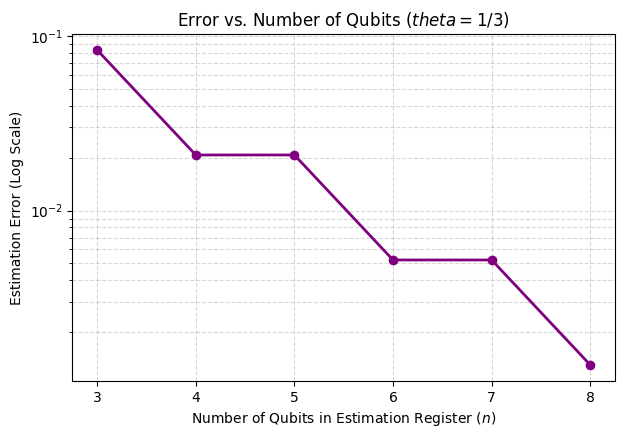

In [18]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)
    gate = UnitaryGate(u, label = f"uROT{k}")
    return gate.control(1)
def QFT(inputs):
    qc = QuantumCircuit(inputs)
    n = len(inputs)
    for t in reversed(range(n)):
        qc.h(inputs[t])
        for ctrl in reversed(range(t+1,n)):
            k = ctrl-t+1
            qc.append(u_ROT(k), [inputs[ctrl],inputs[t]])
    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])
    gate = qc.to_gate(label= f"QFT{n}")
    return gate
def u_op_k(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j*k/3)]
    ], dtype = complex)
    gate = UnitaryGate(u, label = "U")
    return gate.control(1)
true_phase = 1/3
qubit_range = range(3,9)
errors=[]

sim = AerSimulator()
for n_bits in qubit_range:
    estimation = QuantumRegister(n_bits,"x")
    unitary = QuantumRegister(1,"y")
    c_reg = ClassicalRegister(n_bits,"c")
    qc = QuantumCircuit(estimation, unitary, c_reg)
    qc.h(estimation)
    qc.x(unitary[0])
    for t in range(n_bits):
        qc.append(u_op_k(2**t), [estimation[t],unitary[0]])
    qc.append(QFT(estimation).inverse(), estimation)
    qc.measure(estimation, c_reg)

    tqc = transpile(qc, sim)
    job = sim.run(tqc, shots=1024)
    result = job.result()
    counts = result.get_counts()    

    most_frequent_bitstring = max(counts, key=counts.get)
    decimal_value = int(most_frequent_bitstring,2)

    estimated_phase = decimal_value/(2**n_bits)
    error = abs(true_phase - estimated_phase)
    errors.append(error)

plt.figure(figsize=(7, 4.5))
plt.plot(list(qubit_range), errors, marker='o', color='purple', linestyle='-', linewidth=2)
plt.yscale('log') 
plt.xlabel('Number of Qubits in Estimation Register ($n$)')
plt.ylabel('Estimation Error (Log Scale)')
plt.title('Error vs. Number of Qubits ($\ttheta = 1/3$)')
plt.xticks(list(qubit_range))
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Quantum Phase Estimation Error Analysis using Qiskit

This project analyzes the accuracy of the **Quantum Phase Estimation (QPE)** algorithm by studying how the estimation error changes with the number of qubits in the estimation register.

The phase being estimated is:

\[
\theta = \frac{1}{3}
\]

The program:

1. Implements Quantum Phase Estimation
2. Runs simulations for different estimation-register sizes
3. Extracts the estimated phase
4. Computes estimation error
5. Plots error versus number of qubits

---

# Imports

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
```

These libraries are used for:

- Constructing quantum circuits
- Creating unitary operators
- Running quantum simulations
- Plotting estimation errors

---

# Controlled Rotation Gate

## Definition

```python
def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)

    gate = UnitaryGate(u, label = f"uROT{k}")

    return gate.control(1)
```

This function creates the controlled phase rotation gate:

\[
R_k =
\begin{bmatrix}
1 & 0 \\
0 & e^{\frac{2\pi i}{2^k}}
\end{bmatrix}
\]

used in the QFT implementation.

---

# Quantum Fourier Transform

## QFT Function

```python
def QFT(inputs):
    qc = QuantumCircuit(inputs)

    n = len(inputs)

    for t in reversed(range(n)):

        qc.h(inputs[t])

        for ctrl in reversed(range(t+1,n)):

            k = ctrl - t + 1

            qc.append(
                u_ROT(k),
                [inputs[ctrl], inputs[t]]
            )

    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])

    gate = qc.to_gate(label=f"QFT{n}")

    return gate
```

The QFT circuit is implemented using:

- Hadamard gates
- Controlled phase rotations
- Swap operations

---

# Controlled Unitary Operator

## Definition

```python
def u_op_k(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j*k/3)]
    ], dtype = complex)

    gate = UnitaryGate(u, label = "U")

    return gate.control(1)
```

This unitary operator has eigenvalue:

\[
e^{2\pi i k/3}
\]

corresponding to the phase:

\[
\theta = \frac{1}{3}
\]

---

# True Phase Value

```python
true_phase = 1/3
```

Defines the exact phase value to compare against the estimated phase.

---

# Estimation Register Sizes

```python
qubit_range = range(3,9)
```

The QPE algorithm is tested using:

\[
n = 3,4,5,6,7,8
\]

estimation qubits.

---

# Error Storage

```python
errors = []
```

Stores the estimation error for each register size.

---

# Aer Simulator

```python
sim = AerSimulator()
```

Creates the quantum simulator backend.

---

# Running QPE for Different Qubit Counts

```python
for n_bits in qubit_range:
```

The algorithm is repeated for different estimation-register sizes.

---

# Register Initialization

```python
estimation = QuantumRegister(n_bits,"x")

unitary = QuantumRegister(1,"y")

c_reg = ClassicalRegister(n_bits,"c")
```

Creates:

- Estimation register
- Eigenstate qubit
- Classical measurement register

---

# Circuit Creation

```python
qc = QuantumCircuit(estimation, unitary, c_reg)
```

Initializes the quantum circuit.

---

# State Preparation

```python
qc.h(estimation)

qc.x(unitary[0])
```

- Estimation qubits are placed into equal superposition
- The eigenstate qubit is initialized to:

\[
|1\rangle
\]

---

# Applying Controlled Unitary Powers

```python
for t in range(n_bits):

    qc.append(
        u_op_k(2**t),
        [estimation[t], unitary[0]]
    )
```

Applies:

\[
U^{2^0}, U^{2^1}, U^{2^2}, \dots
\]

to encode the phase information.

---

# Applying the Inverse QFT

```python
qc.append(
    QFT(estimation).inverse(),
    estimation
)
```

The inverse QFT extracts the phase estimate from the amplitudes.

---

# Measurement

```python
qc.measure(estimation, c_reg)
```

Measures the estimation register.

---

# Simulation

```python
tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)

result = job.result()

counts = result.get_counts()
```

The circuit is:

1. Transpiled
2. Simulated
3. Measured

---

# Extracting the Estimated Phase

```python
most_frequent_bitstring = max(counts, key=counts.get)

decimal_value = int(most_frequent_bitstring, 2)

estimated_phase = decimal_value / (2**n_bits)
```

Steps:

1. Find the most probable output bitstring
2. Convert it to decimal
3. Divide by \(2^n\) to obtain the estimated phase

---

# Error Calculation

```python
error = abs(true_phase - estimated_phase)

errors.append(error)
```

Computes the absolute estimation error.

---

# Plotting Error vs Qubit Count

```python
plt.figure(figsize=(7, 4.5))

plt.plot(
    list(qubit_range),
    errors,
    marker='o',
    color='purple',
    linestyle='-',
    linewidth=2
)

plt.yscale('log')

plt.xlabel('Number of Qubits in Estimation Register ($n$)')

plt.ylabel('Estimation Error (Log Scale)')

plt.title('Error vs. Number of Qubits ($\\theta = 1/3$)')

plt.xticks(list(qubit_range))

plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()
```

The graph shows how estimation accuracy improves as the number of estimation qubits increases.

A logarithmic y-axis is used to better visualize the reduction in error.

---

# Complete Code

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def u_ROT(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j/(2**k))]
    ], dtype = complex)

    gate = UnitaryGate(u, label = f"uROT{k}")

    return gate.control(1)

def QFT(inputs):
    qc = QuantumCircuit(inputs)

    n = len(inputs)

    for t in reversed(range(n)):

        qc.h(inputs[t])

        for ctrl in reversed(range(t+1,n)):

            k = ctrl - t + 1

            qc.append(
                u_ROT(k),
                [inputs[ctrl], inputs[t]]
            )

    for i in range(n//2):
        qc.swap(inputs[i], inputs[n-i-1])

    gate = qc.to_gate(label=f"QFT{n}")

    return gate

def u_op_k(k):
    u = np.array([
        [1,0],
        [0,np.exp(2*np.pi*1j*k/3)]
    ], dtype = complex)

    gate = UnitaryGate(u, label = "U")

    return gate.control(1)

true_phase = 1/3

qubit_range = range(3,9)

errors = []

sim = AerSimulator()

for n_bits in qubit_range:

    estimation = QuantumRegister(n_bits, "x")

    unitary = QuantumRegister(1, "y")

    c_reg = ClassicalRegister(n_bits, "c")

    qc = QuantumCircuit(estimation, unitary, c_reg)

    qc.h(estimation)

    qc.x(unitary[0])

    for t in range(n_bits):

        qc.append(
            u_op_k(2**t),
            [estimation[t], unitary[0]]
        )

    qc.append(
        QFT(estimation).inverse(),
        estimation
    )

    qc.measure(estimation, c_reg)

    tqc = transpile(qc, sim)

    job = sim.run(tqc, shots=1024)

    result = job.result()

    counts = result.get_counts()

    most_frequent_bitstring = max(counts, key=counts.get)

    decimal_value = int(most_frequent_bitstring, 2)

    estimated_phase = decimal_value / (2**n_bits)

    error = abs(true_phase - estimated_phase)

    errors.append(error)

plt.figure(figsize=(7, 4.5))

plt.plot(
    list(qubit_range),
    errors,
    marker='o',
    color='purple',
    linestyle='-',
    linewidth=2
)

plt.yscale('log')

plt.xlabel('Number of Qubits in Estimation Register ($n$)')

plt.ylabel('Estimation Error (Log Scale)')

plt.title('Error vs. Number of Qubits ($\\theta = 1/3$)')

plt.xticks(list(qubit_range))

plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()
```

---

# Mathematical Background

Quantum Phase Estimation estimates the phase:

\[
U|u\rangle
=
e^{2\pi i\theta}|u\rangle
\]

where:

- \(U\) is a unitary operator
- \(|u\rangle\) is an eigenvector
- \(\theta\) is the unknown phase

The precision improves approximately as:

\[
\text{Error} \propto \frac{1}{2^n}
\]

where \(n\) is the number of estimation qubits.

---

# Expected Observation

As the number of qubits increases:

- The phase estimate becomes more accurate
- The estimation error decreases exponentially
- The graph should show a nearly linear decrease on a logarithmic scale

---